In [1]:
import matplotlib.pyplot as plt
import torch

from cryosim.crowding import poisson_disk_neighbors_3d

%load_ext autoreload
%autoreload 2

In [43]:
def filter_by_z_density(
    pts: torch.Tensor,
    z_length: float,
    sigma_frac: float = 0.05,
    peak_amplitude: float = 1.0,
    baseline: float = 0.1,
    curve_points: int = 200,
):
    """
    Filter points based on a two-Gaussian z-density profile with peaks at the
    top and bottom of the z-range.

    Args:
        pts: (N,3) tensor of (x,y,z) coordinates.
        z_length: extent of the z-axis (same units as pts[:,2]).
        sigma_frac: Gaussian width as fraction of z_length.
        peak_amplitude: amplitude of Gaussian peaks.
        baseline: minimum probability in the bulk.
        curve_points: number of points for returning the probability curve along z.

    Returns:
        pts_filtered: (M,3) tensor of points that were kept.
        probs_filtered: (M,) tensor of p(z) values for the kept points.
        z_curve: (curve_points,) tensor of z positions for the probability curve.
        p_curve: (curve_points,) tensor of probability values for the curve.
    """
    z_min, z_max = -z_length / 2, z_length / 2
    sigma = sigma_frac * z_length

    # compute z for each point
    z_pts = pts[:, 2]

    # Gaussian peaks at top and bottom
    g1 = torch.exp(-0.5 * ((z_pts - z_min) / sigma) ** 2)
    g2 = torch.exp(-0.5 * ((z_pts - z_max) / sigma) ** 2)

    # acceptance probability for each point
    probs_filtered = baseline + peak_amplitude * (g1 + g2)
    probs_filtered = (probs_filtered / probs_filtered.max()).clamp(0.0, 1.0)

    # filter points randomly
    mask = torch.rand(len(z_pts)) < probs_filtered
    pts_filtered = pts[mask]
    probs_filtered = probs_filtered[mask]

    # create probability curve along z
    z_curve = torch.linspace(z_min, z_max, curve_points)
    g1_curve = torch.exp(-0.5 * ((z_curve - z_min) / sigma) ** 2)
    g2_curve = torch.exp(-0.5 * ((z_curve - z_max) / sigma) ** 2)
    p_curve = baseline + peak_amplitude * (g1_curve + g2_curve)
    z_distribution = (p_curve / p_curve.max()).clamp(0.0, 1.0)

    return pts_filtered, z_distribution

In [44]:
# Step 1: uniform Poisson-disk sampling
pts = poisson_disk_neighbors_3d(min_distance=60.0, box=(100, 500, 500), seed="random")

# Step 2: apply z-bias filtering
pts_filtered, probs, z_curve, p_curve = filter_by_z_density(
    pts,
    box=(100, 200, 200),
    peak_offset=5.0,  # distance from surfaces
    sigma_frac=0.05,  # relative width of the peaks
    peak_amplitude=1.0,
)

print(
    f"{len(pts_filtered)} points kept of {len(pts)} ({len(pts_filtered) / len(pts):.1%})"
)

39 points kept of 109 (35.8%)


(0.0, 1.0)

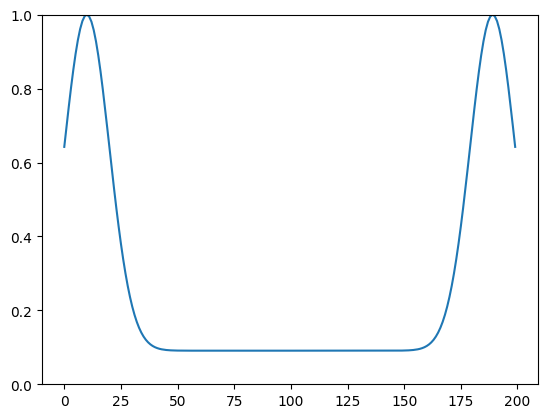

In [45]:
plt.plot(p_curve)
plt.ylim(0, 1)

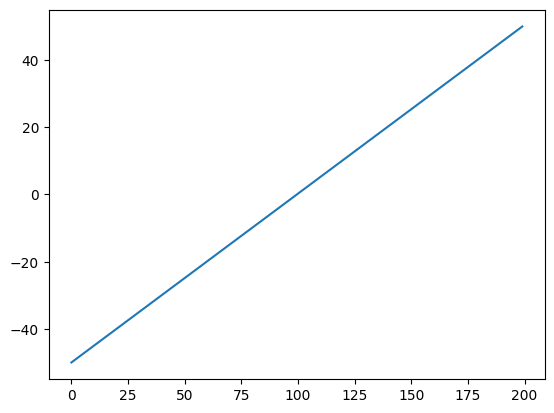

In [49]:
plt.plot(z_curve)
# plt.ylim(0,1)

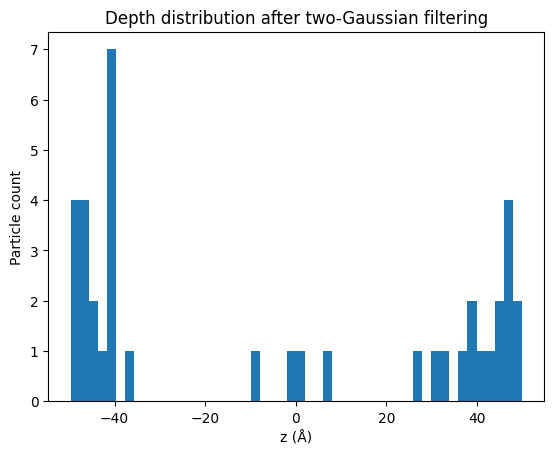

In [46]:
plt.hist(pts_filtered[:, 2].numpy(), bins=50)
plt.xlabel("z (Å)")
plt.ylabel("Particle count")
plt.title("Depth distribution after two-Gaussian filtering")
plt.show()

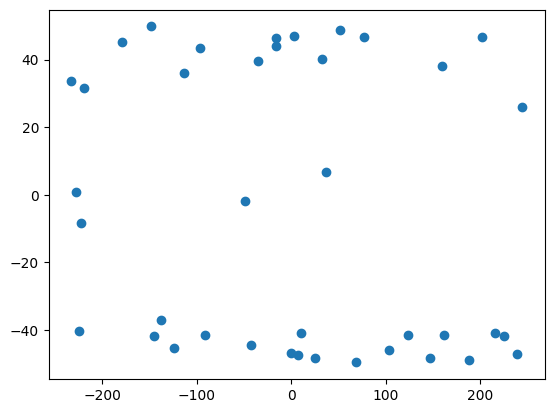

In [47]:
plt.scatter(pts_filtered[:, 0], pts_filtered[:, 2])